In [77]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression, SGDRegressor
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

In [119]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

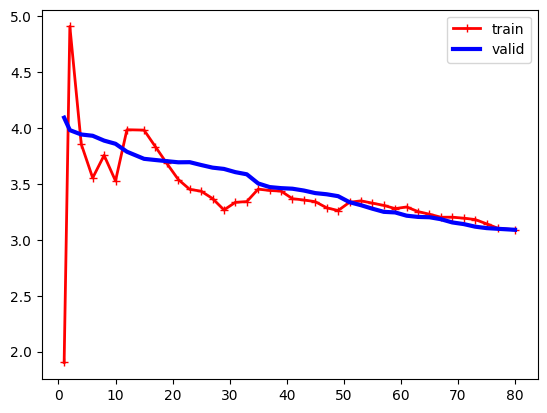

In [81]:
sgd_reg = SGDRegressor(random_state=42)

train_sizes, train_scores, valid_scores = learning_curve(
                sgd_reg, X, y.ravel(), train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
                scoring="neg_root_mean_squared_error", exploit_incremental_learning=True)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.legend()
plt.show()

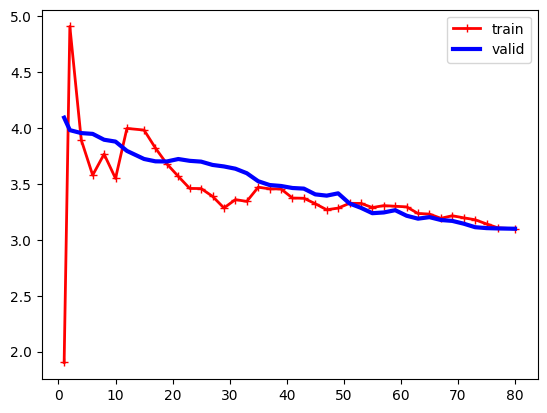

In [91]:

import learning_curve
reload(learning_curve)
from learning_curve import learning_curve
sgd_reg = SGDRegressor(random_state=42)

train_sizes, train_scores, valid_scores = learning_curve(
                sgd_reg, X, y.ravel(), train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
                scoring="root_mean_squared_error", exploit_incremental_learning=True)

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.legend()
plt.show()

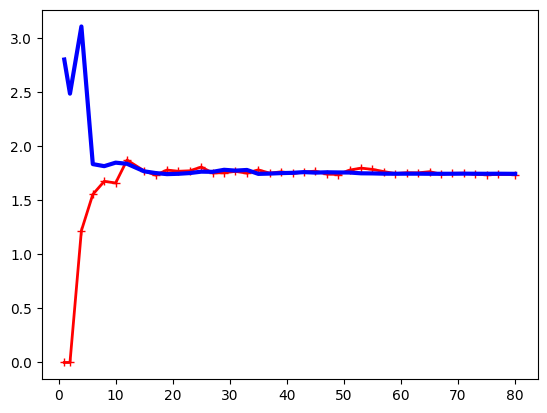

In [63]:
train_sizes, train_scores, valid_scores = learning_curve(
                LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
                scoring="neg_root_mean_squared_error", exploit_incremental_learning=False)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

plt.show()

In [64]:
train_sizes

array([ 1,  2,  4,  6,  8, 10, 12, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67,
       69, 71, 73, 75, 77, 80])

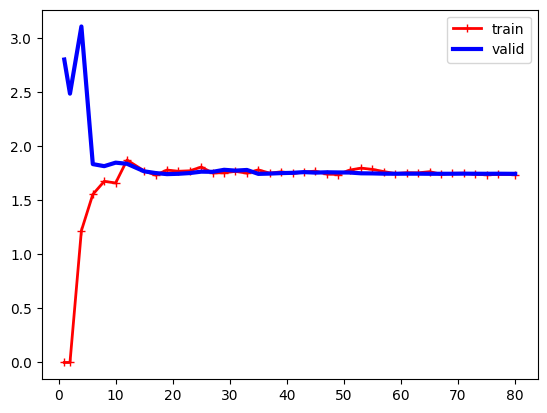

In [92]:
import learning_curve
reload(learning_curve)
from learning_curve import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
                LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
                scoring="root_mean_squared_error")

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend()
plt.show()

In [67]:
train_sizes

array([ 1,  2,  4,  6,  8, 10, 12, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67,
       69, 71, 73, 75, 77, 80])

In [19]:
np.linspace(0.01, 1.0, 40)

array([0.01      , 0.03538462, 0.06076923, 0.08615385, 0.11153846,
       0.13692308, 0.16230769, 0.18769231, 0.21307692, 0.23846154,
       0.26384615, 0.28923077, 0.31461538, 0.34      , 0.36538462,
       0.39076923, 0.41615385, 0.44153846, 0.46692308, 0.49230769,
       0.51769231, 0.54307692, 0.56846154, 0.59384615, 0.61923077,
       0.64461538, 0.67      , 0.69538462, 0.72076923, 0.74615385,
       0.77153846, 0.79692308, 0.82230769, 0.84769231, 0.87307692,
       0.89846154, 0.92384615, 0.94923077, 0.97461538, 1.        ])

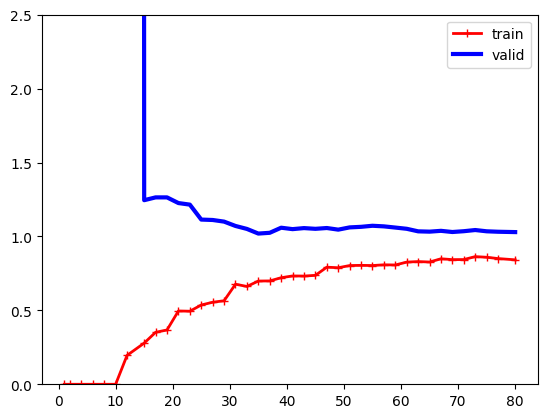

In [121]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
import learning_curve
reload(learning_curve)
from learning_curve import learning_curve

polynomial_regression = make_pipeline(
        PolynomialFeatures(degree=10, include_bias=False),
        LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
        polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
        scoring="root_mean_squared_error")

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

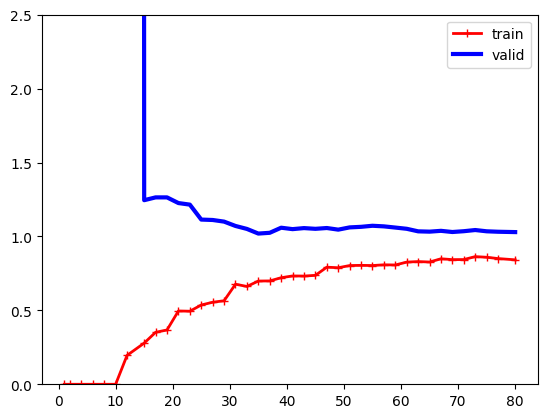

In [120]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve


polynomial_regression = make_pipeline(
        PolynomialFeatures(degree=10, include_bias=False),
        LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
        polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
        scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

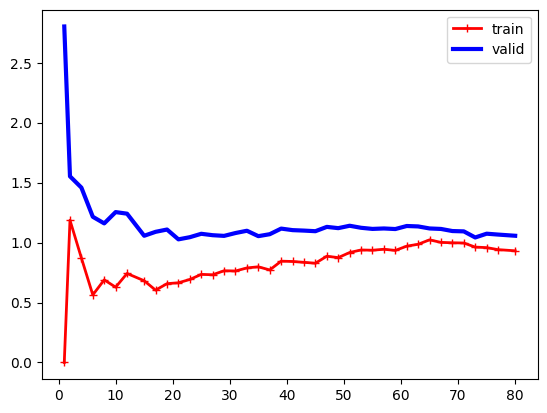

In [134]:
import learning_curve
reload(learning_curve)
from learning_curve import learning_curve
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(random_state=42, n_estimators=10, max_depth=2)

train_sizes, train_scores, valid_scores = learning_curve(
        forest, X, y.ravel(), train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
        scoring="root_mean_squared_error")

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend()
plt.show()

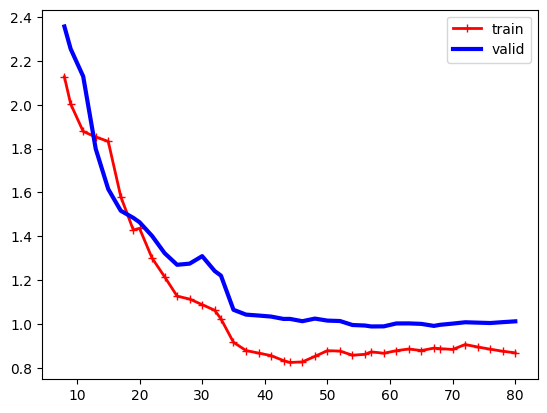

In [136]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(8)

train_sizes, train_scores, valid_scores = learning_curve(
        knn, X, y, train_sizes=np.linspace(0.1, 1.0, 40), cv=5,
        scoring="root_mean_squared_error")

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend()
plt.show()

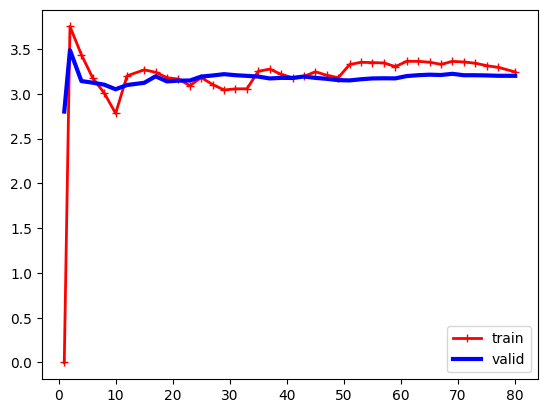

In [130]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

train_sizes, train_scores, valid_scores = learning_curve(
        tree, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
        scoring="root_mean_squared_error")

train_errors = train_scores.mean(axis=1)
valid_errors = valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend()
plt.show()

*с dataset-a за life satisfaction да се обучи модел линеен модел с polynomial regression*

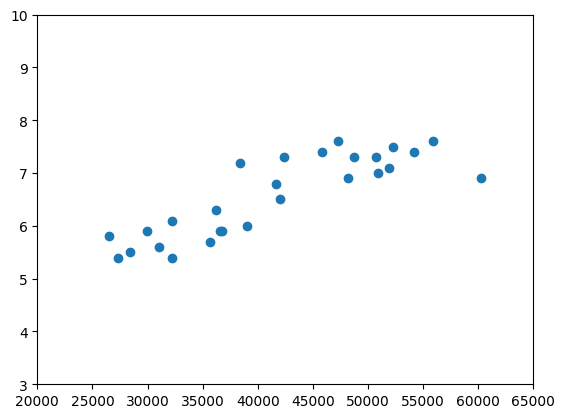

In [99]:
import pandas as pd

data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

plt.scatter(X, y)
plt.ylim(3, 10)
plt.xlim(20000, 65000)
plt.show()

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

poly_reg = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

grid = {
    'poly__degree': [1, 2, 3, 4, 10, 50]
}

grid_search = GridSearchCV(poly_reg, grid, cv=4, scoring='neg_root_mean_squared_error', return_train_score=True)
grid_search.fit(X, y)

,estimator,Pipeline(step...egression())])
,param_grid,"{'poly__degree': [1, 2, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,degree,1


In [107]:
pd.DataFrame(grid_search.cv_results_)[['param_poly__degree', 'mean_test_score', 'mean_train_score']].sort_values('mean_test_score', ascending=False)

,param_poly__degree,mean_test_score,mean_train_score
0,1,-0.505055,-0.377867
1,2,-0.752659,-0.331351
2,3,-0.920711,-0.305007
3,4,-1.029474,-0.306437
4,10,-1.096839,-0.320170
5,50,-309060.135509,-0.607403


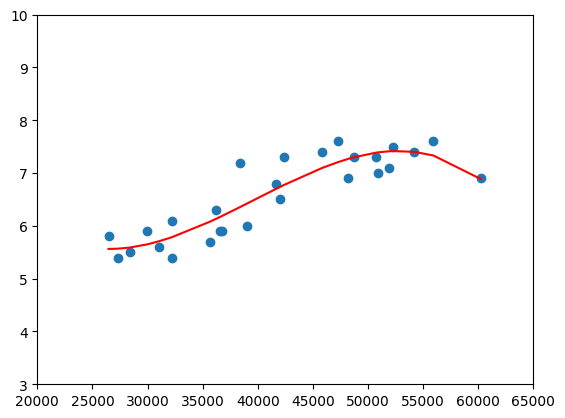

In [118]:
poly_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

poly_reg.fit(X, y)
y_pred = poly_reg.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, 'r-')
plt.ylim(3, 10)
plt.xlim(20000, 65000)
plt.show()